# Single Cell RNA Seq Data Analysis using Seurat_part_2

In [15]:
# Ensure plots render inline
options(jupyter.plot_mimetypes = c("image/png"))

In [14]:
# load data from 10x Genomics
lung.seurat.obj <- readRDS("/home/jovyan/lung_seurat_NSCLC.rds")

In [16]:
# Load library
library(Seurat)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




### Clustering the Data

In [17]:
# Clustering the Data
lung.seurat.obj <- FindNeighbors(lung.seurat.obj, dims = 1:15)
lung.seurat.obj <- FindClusters(lung.seurat.obj, resolution = c(0.1, 0.3, 0.5, 0.7, 1))

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 24859
Number of edges: 789594

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9694
Number of communities: 9
Elapsed time: 2 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 24859
Number of edges: 789594

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9403
Number of communities: 14
Elapsed time: 2 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 24859
Number of edges: 789594

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9160
Number of communities: 17
Elapsed time: 2 seconds
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 24859
Number of edges: 789594

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8941
Number of communities: 19
Elapsed time: 2 seconds
Modularity Op

In [18]:
#set the identity of cells based on a specific resolution (resolution 0.3)
Idents(lung.seurat.obj) <- "RNA_snn_res.0.3"

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
09:40:40 UMAP embedding parameters a = 0.9922 b = 1.112

09:40:40 Read 24859 rows and found 15 numeric columns

09:40:40 Using Annoy for neighbor search, n_neighbors = 30

09:40:40 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

09:40:42 Writing NN index file to temp file /tmp/Rtmp2pFB2k/file12f77a92ed

09:40:42 Searching Annoy index using 1 thread, search_k = 3000

09:40:47 Annoy recall = 100%

09:40:47 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 

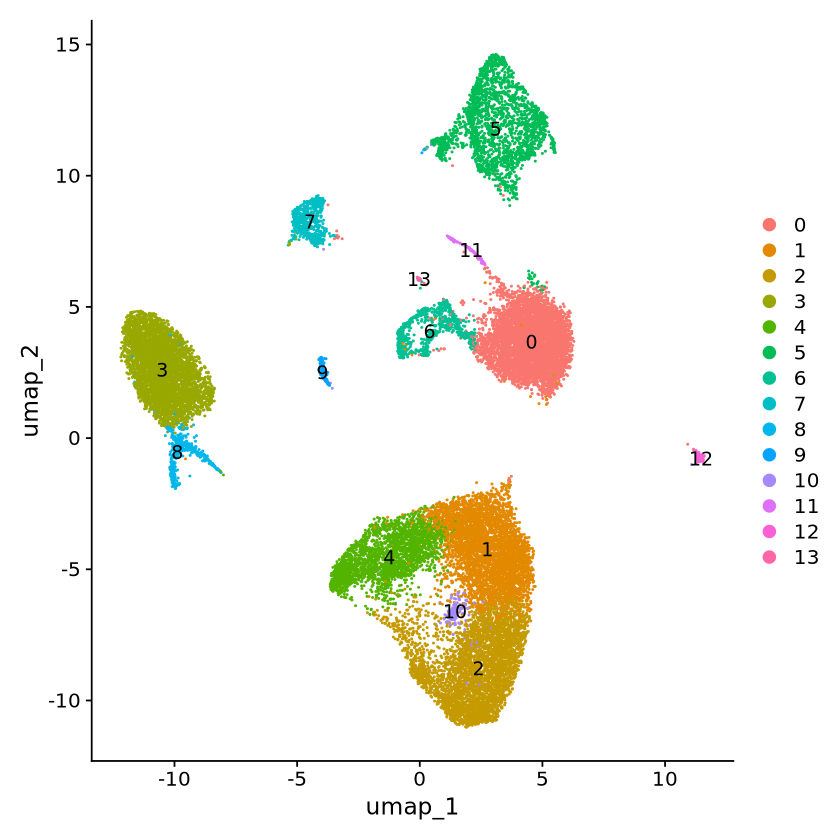

In [19]:
lung.seurat.obj <- RunUMAP(lung.seurat.obj, dims = 1:15)
# Plotting UMAP
DimPlot(lung.seurat.obj, reduction = "umap", label = TRUE)

## Cell Type Annotation

In [20]:
# Load necessary library
library(dplyr)
library(ggplot2)
library(SingleR)
library(celldex) # 


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeigh

In [21]:
# Download a reference dataset from celldex.
# HumanPrimaryCellAtlasData is a common and robust choice.
ref.data <- HumanPrimaryCellAtlasData()

see ?celldex and browseVignettes('celldex') for documentation

loading from cache

see ?celldex and browseVignettes('celldex') for documentation

loading from cache



Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 5.8 GiB”


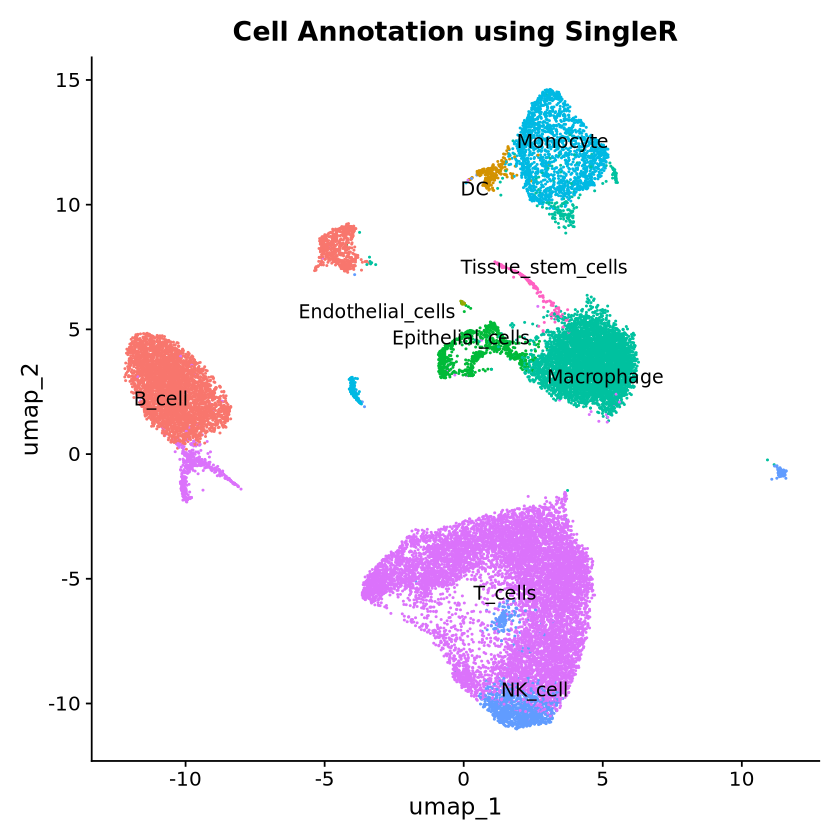

In [22]:
library(SingleR)

# Use RNA assay counts (or log-normalized counts)
expr.mat <- as.matrix(GetAssayData(lung.seurat.obj, slot = "data"))  # log-normalized
# or for raw counts
# expr.mat <- as.matrix(GetAssayData(lung.seurat.obj, slot = "counts"))

# 4. Run SingleR at cluster level (using Leiden clusters)
pred.cluster <- SingleR(
  test = expr.mat,
  ref = ref.data,
  labels = ref.data$label.main,
  clusters = lung.seurat.obj$seurat_clusters
)

# 5. Map cluster annotations back to cells
cluster.annotations <- pred.cluster$labels
names(cluster.annotations) <- rownames(pred.cluster)
cell.annotations <- cluster.annotations[as.character(lung.seurat.obj$seurat_clusters)]
names(cell.annotations) <- colnames(lung.seurat.obj)

# 6. Add to Seurat metadata
lung.seurat.obj <- AddMetaData(
  object = lung.seurat.obj,
  metadata = cell.annotations,
  col.name = "SingleR_cluster"
)

# 7. Visualize annotationsbb
DimPlot(lung.seurat.obj, group.by = "SingleR_cluster", label = TRUE, repel = TRUE) + NoLegend() + ggtitle("Cell Annotation using SingleR")

### Cell Type and Counts

In [24]:
colnames(lung.seurat.obj@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "percent.mt"     
 [5] "RNA_snn_res.0.1" "RNA_snn_res.0.3" "RNA_snn_res.0.5" "RNA_snn_res.0.7"
 [9] "RNA_snn_res.1"   "seurat_clusters" "SingleR_cluster"

In [25]:
table(lung.seurat.obj$SingleR_cluster)


           B_cell                DC Endothelial_cells  Epithelial_cells 
             4611               230                32               828 
       Macrophage          Monocyte           NK_cell           T_cells 
             5492              1955              1298             10230 
Tissue_stem_cells 
              183 

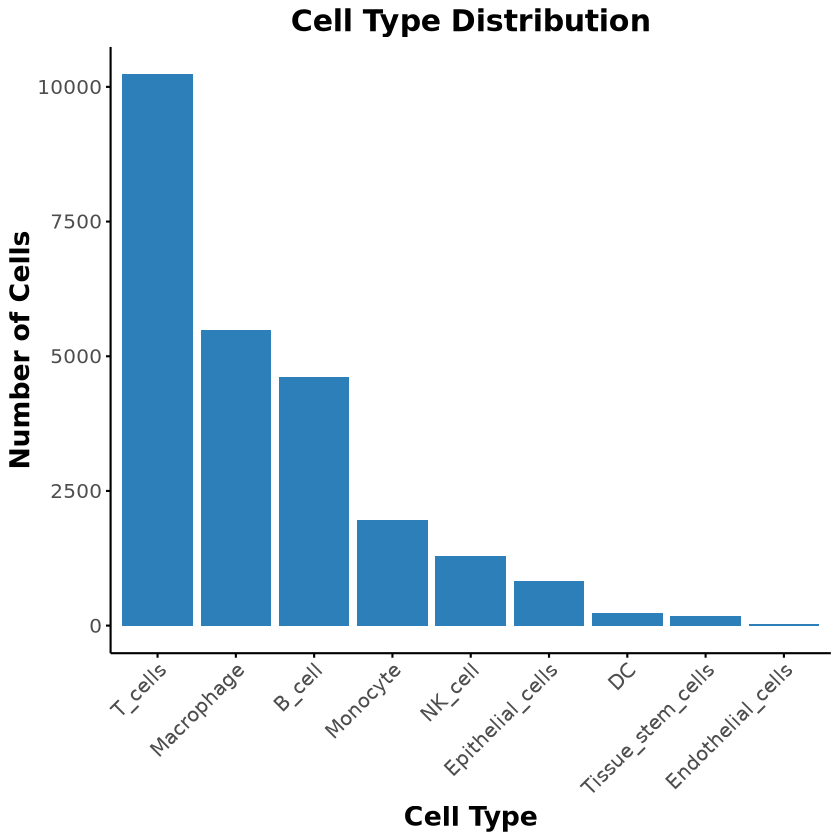

In [29]:
# Load ggplot2
library(ggplot2)

# Data
cell_types <- c("B_cell", "DC", "Endothelial_cells", "Epithelial_cells",
                "Macrophage", "Monocyte", "NK_cell", "T_cells", "Tissue_stem_cells")
counts <- c(4611, 230, 32, 828, 5492, 1955, 1298, 10230, 183)
cell_counts <- data.frame(CellType = cell_types, Count = counts)

# Plot
ggplot(cell_counts, aes(x = reorder(CellType, -Count), y = Count)) +
  geom_bar(stat = "identity", fill = "#2c7fb8") +
  theme_minimal() +
  theme(
    # Remove grid lines
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),

    # Add axis lines
    axis.line = element_line(color = "black", linewidth = 0.6),

    # Add ticks
    axis.ticks = element_line(color = "black", linewidth = 0.6),

    # Customize text sizes
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),

    # Optional: title styling
    plot.title = element_text(size = 18, face = "bold", hjust = 0.5)
  ) +
  labs(title = "Cell Type Distribution",
       x = "Cell Type",
       y = "Number of Cells")

### Differential Expression Analysis for Each Cluster

In [30]:
# Differential expression analysis for each cluster
markers <- FindAllMarkers(lung.seurat.obj, only.pos = TRUE, logfc.threshold = 0.25)
#head(markers)


Calculating cluster 0

Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculatin

In [31]:
# get top marker per cluster
top.markers <- markers %>% group_by(cluster) %>% top_n(n = 5, wt = avg_log2FC)
head(top.markers)

p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
0.001292317,3.624883,0.011,0.007,1,0,COL11A1
0.003529946,3.916855,0.019,0.014,1,0,GPM6A
0.003675625,3.752793,0.017,0.012,1,0,COL2A1
0.004092084,4.244397,0.010,0.006,1,0,BPIFB1
0.005979830,3.726138,0.012,0.008,1,0,SFRP1
0.000000000,3.013783,0.196,0.026,0,1,CD40LG


In [32]:
# Compare each SingleR-annotated cell type against all others
markers_celltype <- FindAllMarkers(
  object = lung.seurat.obj,
  group.by = "SingleR_cluster",
  only.pos = TRUE,
  logfc.threshold = 0.2,
  min.pct = 0.1
)

# View top markers per cell type
top_markers <- markers_celltype %>%
  group_by(cluster) %>%
  slice_max(order_by = avg_log2FC, n = 5) %>%
  ungroup() %>%
  select(cluster, gene, avg_log2FC, pct.1, pct.2, p_val_adj)

top_markers

Calculating cluster Macrophage

Calculating cluster Tissue_stem_cells

Calculating cluster Epithelial_cells

Calculating cluster Monocyte

Calculating cluster NK_cell

Calculating cluster T_cells

Calculating cluster Endothelial_cells

Calculating cluster B_cell

Calculating cluster DC



cluster,gene,avg_log2FC,pct.1,pct.2,p_val_adj
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Macrophage,SNHG25,3.594379,0.191,0.187,6.268268e-06
Macrophage,CXCL1,3.344920,0.116,0.095,1.642640e-07
Macrophage,SFTPB,3.170994,0.136,0.100,1.213986e-19
Macrophage,CLDN4,3.144690,0.120,0.104,8.805781e-05
Macrophage,CCL18,3.024088,0.103,0.079,1.386082e-09
Tissue_stem_cells,MEOX2,8.448442,0.104,0.000,0.000000e+00
Tissue_stem_cells,LMOD1,8.193204,0.180,0.000,0.000000e+00
Tissue_stem_cells,PDE1A,7.889256,0.109,0.000,0.000000e+00
Tissue_stem_cells,PRDM6,7.827593,0.131,0.000,0.000000e+00


## Functional Analysis: GO Biological Process



clusterProfiler v4.17.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

G Yu. Thirteen years of clusterProfiler. The Innovation. 2024,
5(6):100722


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:clusterProfiler’:

    select


The following object is masked from ‘package:dplyr’:

    select




Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

'select()' returned

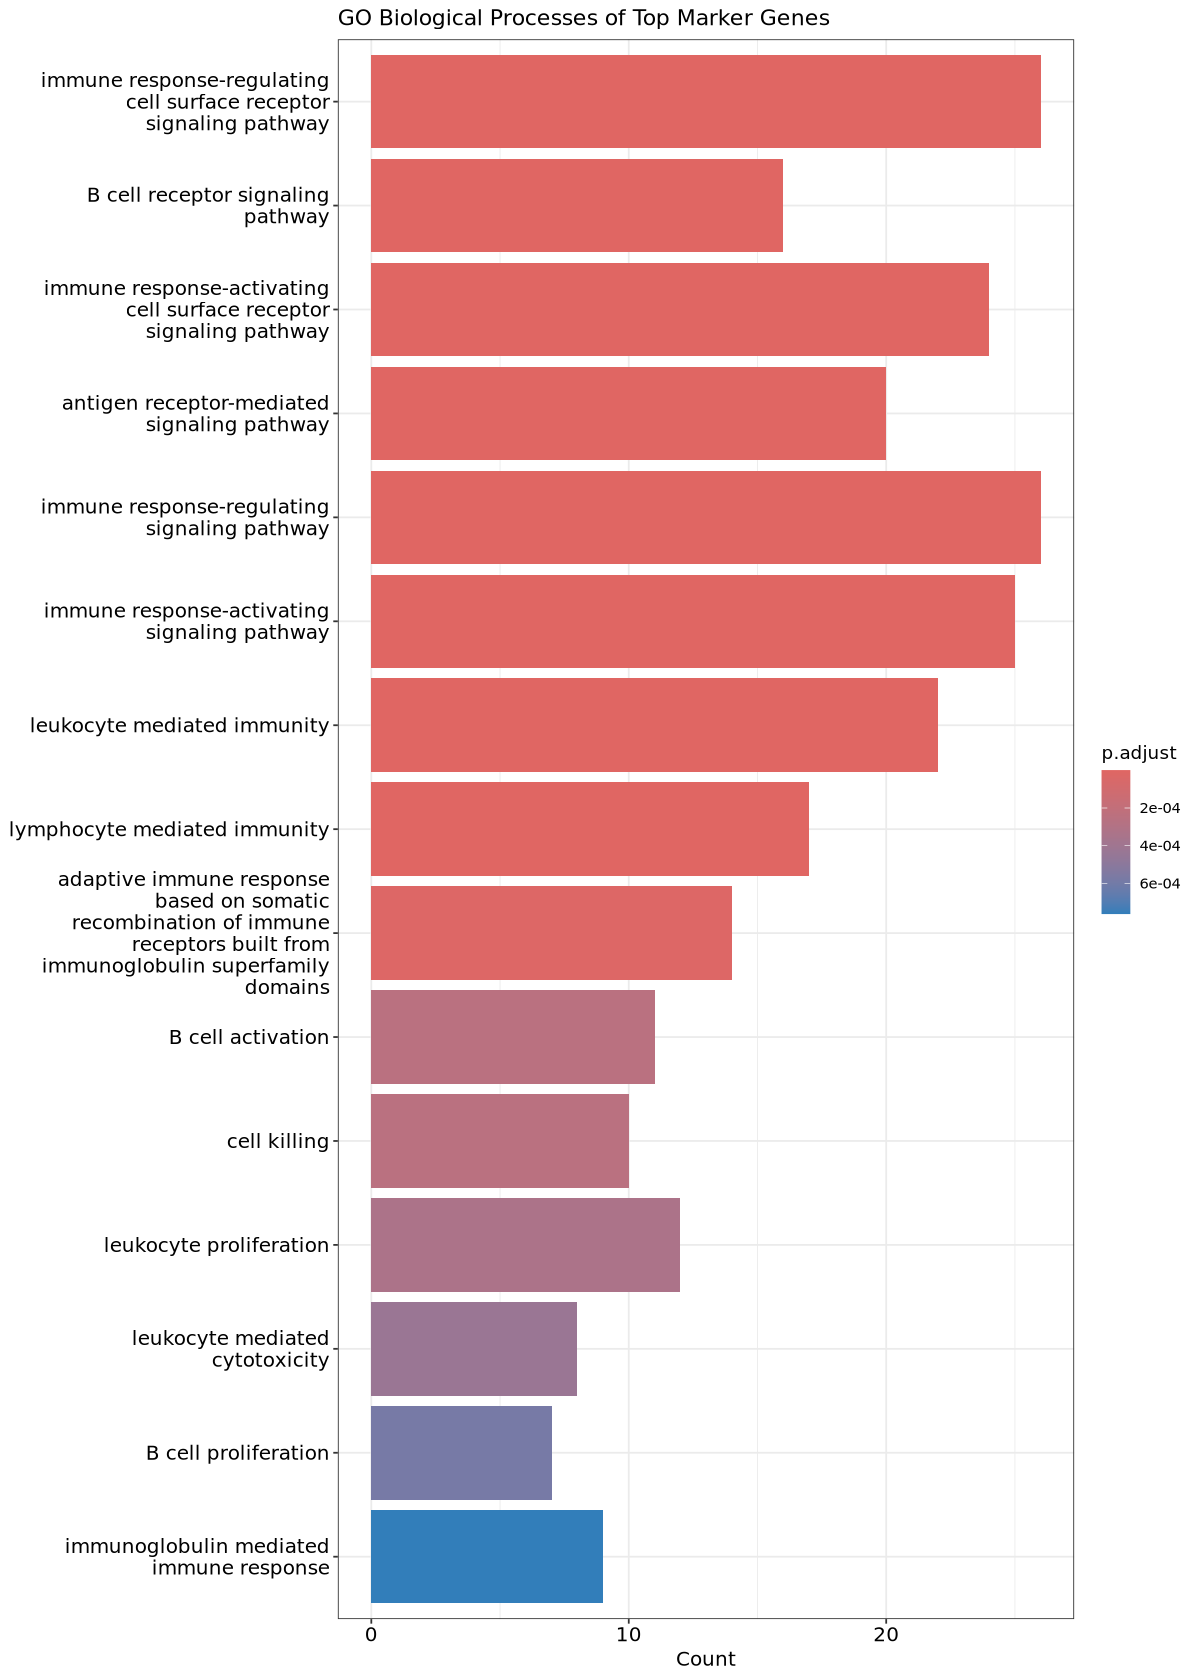

In [33]:
# Load necessary libraries
library(Seurat)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(dplyr)


#  Select top marker genes per cluster (e.g., top 10 by avg_log2FC)
top_markers <- markers_celltype %>%
  group_by(cluster) %>%
  top_n(n = 10, wt = avg_log2FC)

# Map gene symbols to Entrez IDs
gene_entrez <- bitr(unique(top_markers$gene), 
                    fromType = "SYMBOL", 
                    toType = "ENTREZID", 
                    OrgDb = org.Hs.eg.db)

# GO Biological Process enrichment (using marker genes)
ego_bp <- enrichGO(
  gene          = gene_entrez$ENTREZID,
  OrgDb         = org.Hs.eg.db,
  ont           = "BP",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.2,
  readable      = TRUE
)

# Make plot larger
options(repr.plot.width = 10, repr.plot.height = 14)

# Plot top 15 GO BP terms
barplot(ego_bp, showCategory = 15) + 
  ggtitle("GO Biological Processes of Top Marker Genes")
